In [2]:
# Cell 1 — Install and import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [4]:
# Cell 2 — Load RFM data exported from MySQL
rfm = pd.read_csv('D:/Projects/retail-analytics/data/rfm_output.csv')

print("Shape:", rfm.shape)
print("\nColumn names:", list(rfm.columns))
print("\nFirst 5 rows:")
rfm.head()

Shape: (96173, 5)

Column names: ['customer_id', 'last_purchase_date', 'recency_days', 'frequency', 'monetary']

First 5 rows:


,customer_id,last_purchase_date,recency_days,frequency,monetary
0,1617b1357756262bfa56ab541c47bc16,2017-09-29 15:24:52,367,1,13440.0
1,ec5b2ba62e574342386871631fafd3fc,2018-07-15 14:49:44,78,1,7160.0
2,c6e2731c5b391845f6800c97401a43a9,2017-02-12 20:37:36,596,1,6735.0
3,f48d464a0baaea338cb25f816991ab1f,2018-07-25 18:10:17,68,1,6729.0
4,3fd6777bbce08a352fddd04e4a7cc8f6,2017-05-24 18:14:34,495,1,6499.0


In [5]:
# Check for missing values
print("Missing values:")
print(rfm.isnull().sum())

Missing values:
customer_id           0
last_purchase_date    0
recency_days          0
frequency             0
monetary              0
dtype: int64


In [6]:
# Remove any nulls
rfm = rfm.dropna()

In [7]:
# Remove customers with 0 monetary value
rfm = rfm[rfm['monetary'] > 0]

In [8]:
# Remove customers with 0 frequency
rfm = rfm[rfm['frequency'] > 0]

In [10]:
print("Shape after cleaning:", rfm.shape)
print("\nBasic Stats:")
rfm[['recency_days', 'frequency', 'monetary']].describe()

Shape after cleaning: (96173, 5)

Basic Stats:


,recency_days,frequency,monetary
count,96173.000000,96173.0,96173.000000
mean,272.486176,1.0,137.127418
std,152.751527,0.0,209.370853
min,33.000000,1.0,0.850000
25%,149.000000,1.0,45.900000
50%,254.000000,1.0,85.900000
75%,382.000000,1.0,149.900000
max,746.000000,1.0,13440.000000


In [11]:
# ML needs all numbers on the same scale
# Example: monetary goes up to 10000, frequency only goes to 10
# Scaling brings them to the same range so ML treats them equally

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency_days', 'frequency', 'monetary']])


print("Original monetary range:", rfm['monetary'].min(), "to", rfm['monetary'].max())
print("Original recency range:", rfm['recency_days'].min(), "to", rfm['recency_days'].max())
print("\nAfter scaling everything is between -3 and 3 ")
print("Scaled shape:", rfm_scaled.shape)

Original monetary range: 0.85 to 13440.0
Original recency range: 33 to 746

After scaling everything is between -3 and 3 
Scaled shape: (96173, 3)


K=2 done ✅
K=3 done ✅
K=4 done ✅
K=5 done ✅
K=6 done ✅
K=7 done ✅
K=8 done ✅


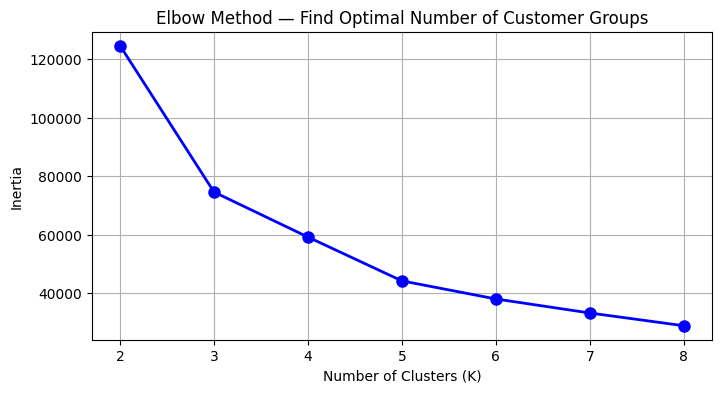


Look at the chart above!
Find where the line stops dropping sharply and flattens out
That is your best K value


In [12]:
# Elbow Method
# This helps us find the best number of customer groups
# Look at the chart — find where the line "bends like an elbow"
# That bend point = best number of clusters

inertia = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
    print(f"K={k} done ✅")

# Plot elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Find Optimal Number of Customer Groups')
plt.grid(True)
plt.xticks(k_range)
plt.show()

print("\nLook at the chart above!")
print("Find where the line stops dropping sharply and flattens out")
print("That is your best K value")

In [13]:
# Cell 6 — Apply KMeans with 4 clusters
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(rfm_scaled)

# See what each cluster looks like on average
cluster_summary = rfm.groupby('Cluster')[['recency_days','frequency','monetary']].mean().round(2)

print("Cluster Summary (averages):")
print(cluster_summary)
print("\nCustomer count per cluster:")
print(rfm['Cluster'].value_counts().sort_index())

Cluster Summary (averages):
         recency_days  frequency  monetary
Cluster                                   
0              120.01        1.0    113.85
1              490.24        1.0    112.29
2              270.51        1.0   1111.97
3              287.43        1.0    112.56

Customer count per cluster:
Cluster
0    35603
1    22498
2     2324
3    35748
Name: count, dtype: int64


In [14]:
# Cell 7 — Label clusters with business names
segment_map = {
    0: 'Recent Customers',
    1: 'Lost Customers',
    2: 'Champions',
    3: 'At Risk'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

print("\nCustomer count per segment:")
print(rfm['Segment'].value_counts())
print("\nAverage spending per segment:")
print(rfm.groupby('Segment')['monetary'].mean().round(2).sort_values(ascending=False))


Customer count per segment:
Segment
At Risk             35748
Recent Customers    35603
Lost Customers      22498
Champions            2324
Name: count, dtype: int64

Average spending per segment:
Segment
Champions           1111.97
Recent Customers     113.85
At Risk              112.56
Lost Customers       112.29
Name: monetary, dtype: float64


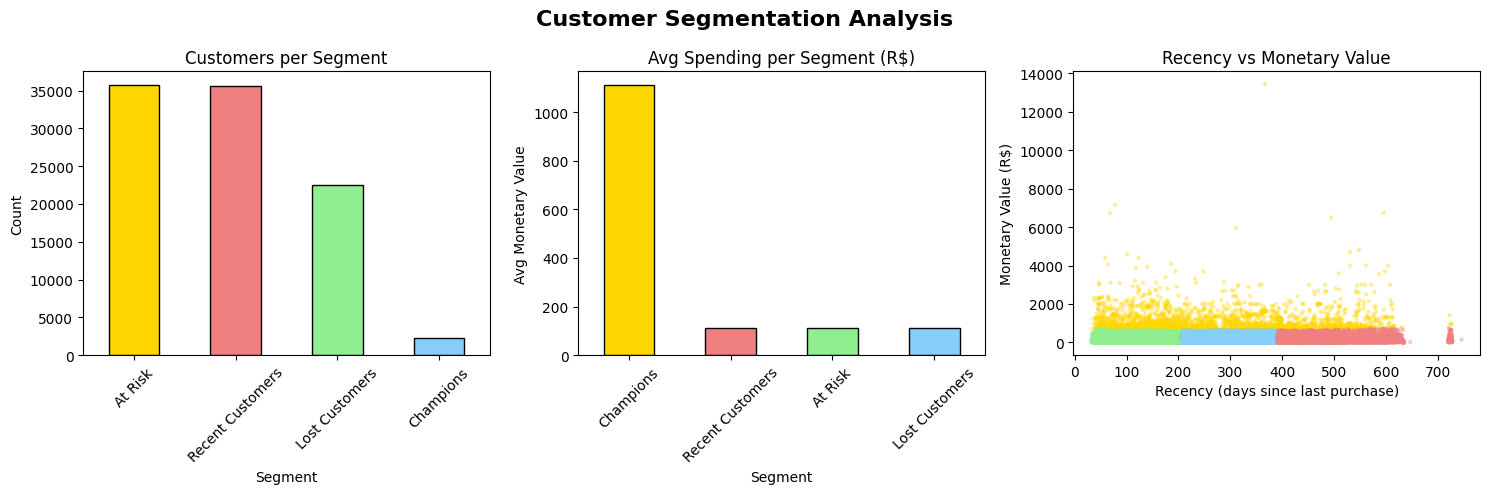

Chart saved!


In [15]:
# Cell 8 — Visualize segments
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Customer Segmentation Analysis', fontsize=16, fontweight='bold')

# Chart 1 — Customer count per segment
colors = ['gold', 'lightcoral', 'lightgreen', 'lightskyblue']
rfm['Segment'].value_counts().plot(
    kind='bar', 
    ax=axes[0], 
    color=colors,
    edgecolor='black'
)
axes[0].set_title('Customers per Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2 — Average spending per segment
rfm.groupby('Segment')['monetary'].mean().sort_values(ascending=False).plot(
    kind='bar',
    ax=axes[1],
    color=colors,
    edgecolor='black'
)
axes[1].set_title('Avg Spending per Segment (R$)')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Avg Monetary Value')
axes[1].tick_params(axis='x', rotation=45)

# Chart 3 — Recency vs Monetary scatter
scatter_colors = rfm['Cluster'].map({
    0: 'lightgreen', 
    1: 'lightcoral', 
    2: 'gold', 
    3: 'lightskyblue'
})
axes[2].scatter(
    rfm['recency_days'], 
    rfm['monetary'], 
    c=scatter_colors,
    alpha=0.3, 
    s=5
)
axes[2].set_title('Recency vs Monetary Value')
axes[2].set_xlabel('Recency (days since last purchase)')
axes[2].set_ylabel('Monetary Value (R$)')

plt.tight_layout()
plt.savefig('D:/Projects/retail-analytics/python/customer_segments.png', dpi=150)
plt.show()
print("Chart saved!")

In [16]:
# Cell 9 — Export final file for Power BI
rfm.to_csv('D:/Projects/retail-analytics/data/rfm_segmented.csv', index=False)


print("\nColumns in the file:")
print(list(rfm.columns))
print("\nTotal customers exported:", len(rfm))
print("\nFinal segment breakdown:")
print(rfm['Segment'].value_counts())



Columns in the file:
['customer_id', 'last_purchase_date', 'recency_days', 'frequency', 'monetary', 'Cluster', 'Segment']

Total customers exported: 96173

Final segment breakdown:
Segment
At Risk             35748
Recent Customers    35603
Lost Customers      22498
Champions            2324
Name: count, dtype: int64
